# Myanmar Territorial Control — Data Exploration

Covers all key questions before modelling:
1. Change distribution over time
2. Direction of transitions
3. How long cells stay stable (spell lengths)
4. Do UCDP events precede changes?
5. Change distribution over space
6. Class persistence
7. Neighbor behavior at change time

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
REPORTS      = PROJECT_ROOT / "reports" / "figures"
REPORTS.mkdir(parents=True, exist_ok=True)

TARGET_PATH   = DATA_PROC / "10_target_variable.parquet"
FEATURES_PATH = DATA_PROC / "myanmar_priogrid_features.csv"

print("Paths configured:")
print(f"  Target:   {TARGET_PATH}")
print(f"  Features: {FEATURES_PATH}")

Paths configured:
  Target:   C:\Users\corne\OneDrive\Nuttige dingen\Verder studeren Spanje\BSE\LEERSTOF\Term3\Thesis\territorial_control_dsdm_master_project\data\processed\10_target_variable.parquet
  Features: C:\Users\corne\OneDrive\Nuttige dingen\Verder studeren Spanje\BSE\LEERSTOF\Term3\Thesis\territorial_control_dsdm_master_project\data\processed\myanmar_priogrid_features.csv


## Load Data

In [4]:
target = pd.read_parquet(TARGET_PATH)
target["year_month"] = target["year_month"].astype(str)
target = target.sort_values(["priogrid_gid", "year_month"]).reset_index(drop=True)

# Load features if available (only needed for section 4)
if FEATURES_PATH.exists():
    features = pd.read_csv(FEATURES_PATH)
    features["year_month"] = features["year_month"].astype(str)
    print("Features loaded.")
else:
    features = None
    print("Features file not found — section 4 will be skipped.")

# Build change flags
target["prev_target"] = target.groupby("priogrid_gid")["target"].shift(1)
target["changed"] = (
    target["prev_target"].notna() &
    (target["target"] != target["prev_target"])
)
target["transition"] = np.where(
    target["changed"],
    target["prev_target"] + " -> " + target["target"],
    "no change"
)

all_months    = sorted(target["year_month"].unique())
all_cells     = sorted(target["priogrid_gid"].unique())
changed_cells = set(target[target["changed"]]["priogrid_gid"].unique())

print(f"{len(target):,} rows | {len(all_cells)} cells | {len(all_months)} months")
print(f"Cells that change at least once: {len(changed_cells)}")
print(f"Total change events: {target['changed'].sum()}")
print(f"\nTarget distribution:")
print(target["target"].value_counts().to_string())

Features file not found — section 4 will be skipped.
5,238 rows | 185 cells | 29 months
Cells that change at least once: 94
Total change events: 255

Target distribution:
target
gov          3303
opo          1110
uncertain     825


## 1. Change Distribution Over Time

How many cells change control in each month? Are changes clustered around specific events?

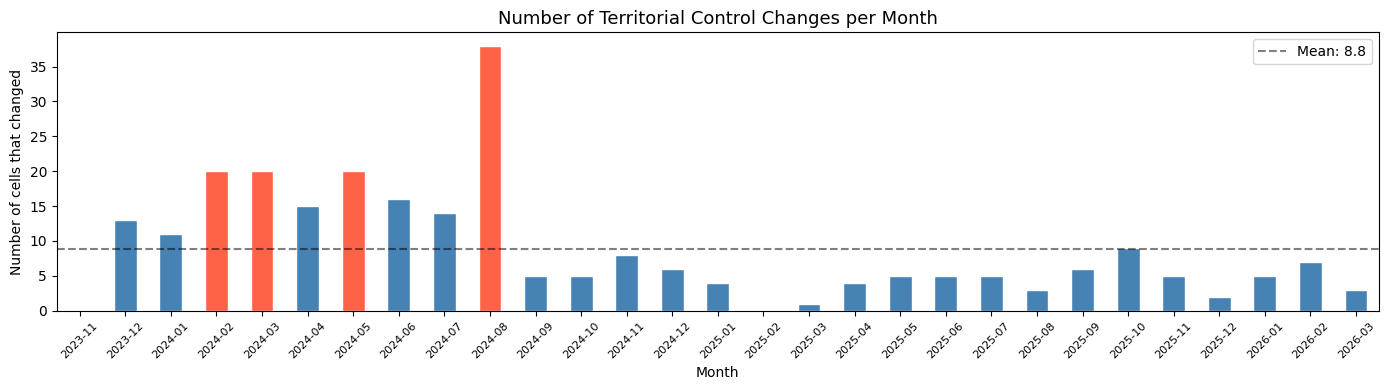

Peak month:          2024-08 (38 changes)
Months with 0 changes: 2
Mean changes/month:  8.8

Full breakdown:
year_month
2023-11     0
2023-12    13
2024-01    11
2024-02    20
2024-03    20
2024-04    15
2024-05    20
2024-06    16
2024-07    14
2024-08    38
2024-09     5
2024-10     5
2024-11     8
2024-12     6
2025-01     4
2025-02     0
2025-03     1
2025-04     4
2025-05     5
2025-06     5
2025-07     5
2025-08     3
2025-09     6
2025-10     9
2025-11     5
2025-12     2
2026-01     5
2026-02     7
2026-03     3


In [5]:
changes_per_month = target[target["changed"]].groupby("year_month").size()
# Fill months with zero changes
changes_per_month = changes_per_month.reindex(all_months, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["tomato" if v > changes_per_month.mean() + changes_per_month.std() 
          else "steelblue" for v in changes_per_month.values]
changes_per_month.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.axhline(changes_per_month.mean(), color="black", linestyle="--", 
           alpha=0.5, label=f"Mean: {changes_per_month.mean():.1f}")
ax.set_title("Number of Territorial Control Changes per Month", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Number of cells that changed")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "01_changes_per_month.png", dpi=150)
plt.show()

print(f"Peak month:          {changes_per_month.idxmax()} ({changes_per_month.max()} changes)")
print(f"Months with 0 changes: {(changes_per_month == 0).sum()}")
print(f"Mean changes/month:  {changes_per_month.mean():.1f}")
print("\nFull breakdown:")
print(changes_per_month.to_string())

## 2. Direction of Transitions

Which transitions are most common? Are changes symmetric (gov→opo similar to opo→gov)?

Transition counts:
transition
gov -> opo          69
opo -> gov          49
uncertain -> gov    45
uncertain -> opo    42
opo -> uncertain    37
gov -> uncertain    13


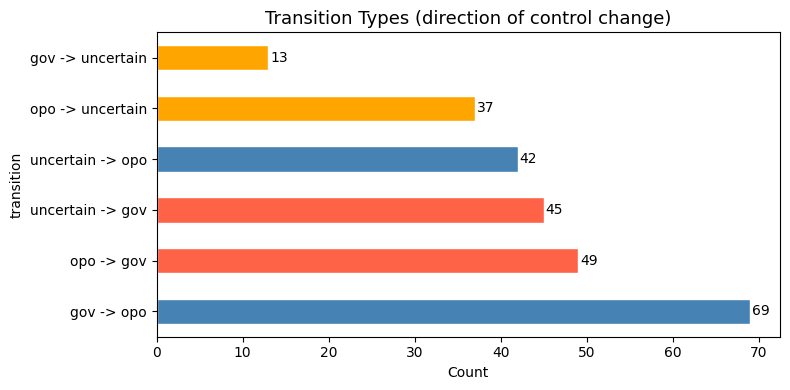


Symmetry check:
  gov->opo: 69 | opo->gov: 49
  gov->uncertain: 13 | uncertain->gov: 45
  opo->gov: 49 | gov->opo: 69
  opo->uncertain: 37 | uncertain->opo: 42
  uncertain->gov: 45 | gov->uncertain: 13
  uncertain->opo: 42 | opo->uncertain: 37


In [6]:
transitions = target[target["changed"]]["transition"].value_counts()
print("Transition counts:")
print(transitions.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tomato" if "gov" in t.split(" -> ")[1] else 
          "steelblue" if "opo" in t.split(" -> ")[1] else "orange" 
          for t in transitions.index]
transitions.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Transition Types (direction of control change)", fontsize=13)
ax.set_xlabel("Count")
for i, v in enumerate(transitions.values):
    ax.text(v + 0.2, i, str(v), va="center", fontsize=10)
plt.tight_layout()
plt.savefig(REPORTS / "02_transition_types.png", dpi=150)
plt.show()

# Symmetry check
print("\nSymmetry check:")
for cls1 in ["gov", "opo", "uncertain"]:
    for cls2 in ["gov", "opo", "uncertain"]:
        if cls1 != cls2:
            t1 = transitions.get(f"{cls1} -> {cls2}", 0)
            t2 = transitions.get(f"{cls2} -> {cls1}", 0)
            if t1 > 0 or t2 > 0:
                print(f"  {cls1}->{cls2}: {t1} | {cls2}->{cls1}: {t2}")

## 3. Spell Lengths — How Long Do Cells Stay Stable?

A spell is a consecutive run of months in the same class. Long spells = high persistence = hard to beat no-change baseline.

Spell length statistics by class:
           count   mean    std  min   25%   50%   75%   max
class                                                      
gov        202.0  16.35  11.33  1.0  4.25  20.0  29.0  29.0
opo        133.0   8.35   9.85  1.0  1.00   2.0  18.0  28.0
uncertain  105.0   7.86   8.62  1.0  2.00   4.0   9.0  29.0


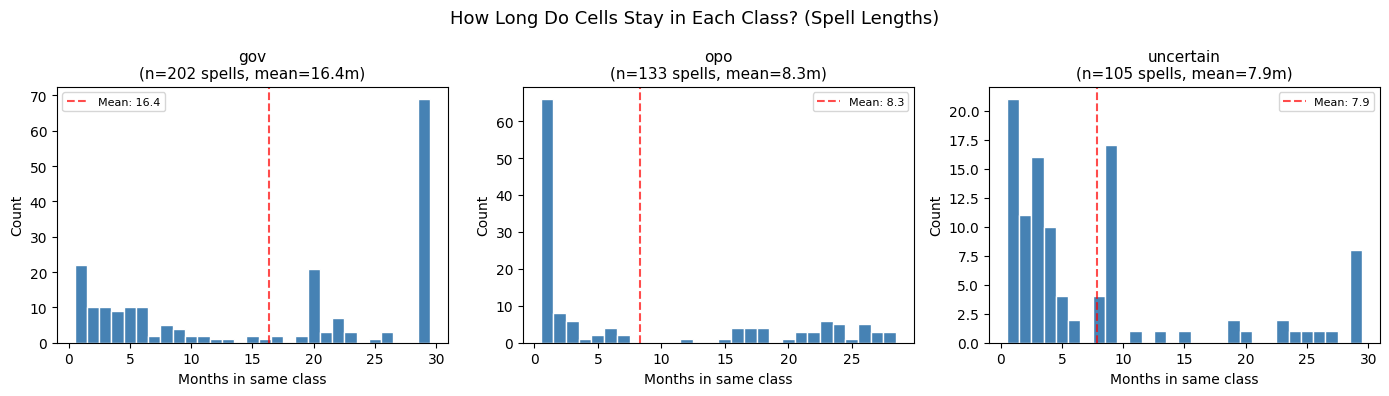


Overall: 440 total spells across 185 cells
Spells of length 1 (immediate flip back): 109


In [7]:
def compute_spells(group):
    spells = []
    current_class = None
    count = 0
    for _, row in group.iterrows():
        if row["target"] != current_class:
            if current_class is not None:
                spells.append({"class": current_class, "length": count,
                               "priogrid_gid": group["priogrid_gid"].iloc[0]})
            current_class = row["target"]
            count = 1
        else:
            count += 1
    if current_class is not None:
        spells.append({"class": current_class, "length": count,
                      "priogrid_gid": group["priogrid_gid"].iloc[0]})
    return spells

all_spells = []
for gid, group in target.groupby("priogrid_gid"):
    all_spells.extend(compute_spells(group))
spells_df = pd.DataFrame(all_spells)

print("Spell length statistics by class:")
print(spells_df.groupby("class")["length"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, cls in enumerate(["gov", "opo", "uncertain"]):
    data = spells_df[spells_df["class"] == cls]["length"]
    axes[i].hist(data, bins=range(1, data.max()+2), color="steelblue",
                 edgecolor="white", align="left")
    axes[i].set_title(f"{cls}\n(n={len(data)} spells, mean={data.mean():.1f}m)", fontsize=11)
    axes[i].set_xlabel("Months in same class")
    axes[i].set_ylabel("Count")
    axes[i].axvline(data.mean(), color="red", linestyle="--", alpha=0.7,
                    label=f"Mean: {data.mean():.1f}")
    axes[i].legend(fontsize=8)

fig.suptitle("How Long Do Cells Stay in Each Class? (Spell Lengths)", fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS / "03_spell_lengths.png", dpi=150)
plt.show()

print(f"\nOverall: {len(spells_df)} total spells across {len(all_cells)} cells")
print(f"Spells of length 1 (immediate flip back): {(spells_df['length']==1).sum()}")

## 4. Do UCDP Events Precede Changes?

The core modelling question: is there more conflict activity in the months before a cell changes control?

In [8]:
if features is not None:
    merged = target.merge(
        features[["priogrid_gid", "year_month", "total_events", "total_fatalities",
                  "total_events_lag1", "total_events_lag3",
                  "total_fatalities_lag1", "total_fatalities_lag3",
                  "gov_event_share", "events_gov", "events_nug"]],
        on=["priogrid_gid", "year_month"], how="left"
    )

    change_months    = merged[merged["changed"] == True]
    no_change_months = merged[merged["changed"] == False]

    compare_cols = ["total_events", "total_fatalities",
                    "total_events_lag1", "total_events_lag3",
                    "total_fatalities_lag1", "total_fatalities_lag3",
                    "gov_event_share", "events_nug"]

    print(f"{'Feature':<30} {'Change months':>14} {'No-change months':>17} {'Ratio':>7}")
    print("-" * 72)
    for col in compare_cols:
        c_mean  = change_months[col].mean()
        nc_mean = no_change_months[col].mean()
        ratio   = c_mean / nc_mean if nc_mean > 0 else float("inf")
        marker  = " <-- HIGH" if ratio > 2 else ""
        print(f"{col:<30} {c_mean:>14.3f} {nc_mean:>17.3f} {ratio:>7.2f}x{marker}")
else:
    print("Skipping section 4 — features file not available.")

Skipping section 4 — features file not available.


In [10]:
if features is not None:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i, col in enumerate(compare_cols):
        ax = axes[i]
        data_c  = change_months[col].dropna()
        data_nc = no_change_months[col].dropna()
        max_val = max(data_c.quantile(0.95), data_nc.quantile(0.95))
        if max_val == 0:
            max_val = 1
        bins = np.linspace(0, max_val, 20)
        ax.hist(data_nc, bins=bins, alpha=0.6, color="steelblue",
                label="No change", density=True)
        ax.hist(data_c, bins=bins, alpha=0.6, color="tomato",
                label="Change", density=True)
        ax.set_title(col, fontsize=9)
        ax.legend(fontsize=7)
        ax.set_xlabel("Value", fontsize=8)

    fig.suptitle("UCDP Feature Distributions: Change vs No-Change Months", fontsize=13)
    plt.tight_layout()
    plt.savefig(REPORTS / "04_events_before_change.png", dpi=150)
    plt.show()
else:
    print("Skipping — features file not available.")

Skipping — features file not available.


## 5. Change Distribution Over Space

Where do changes happen geographically? Are they clustered on specific frontlines?

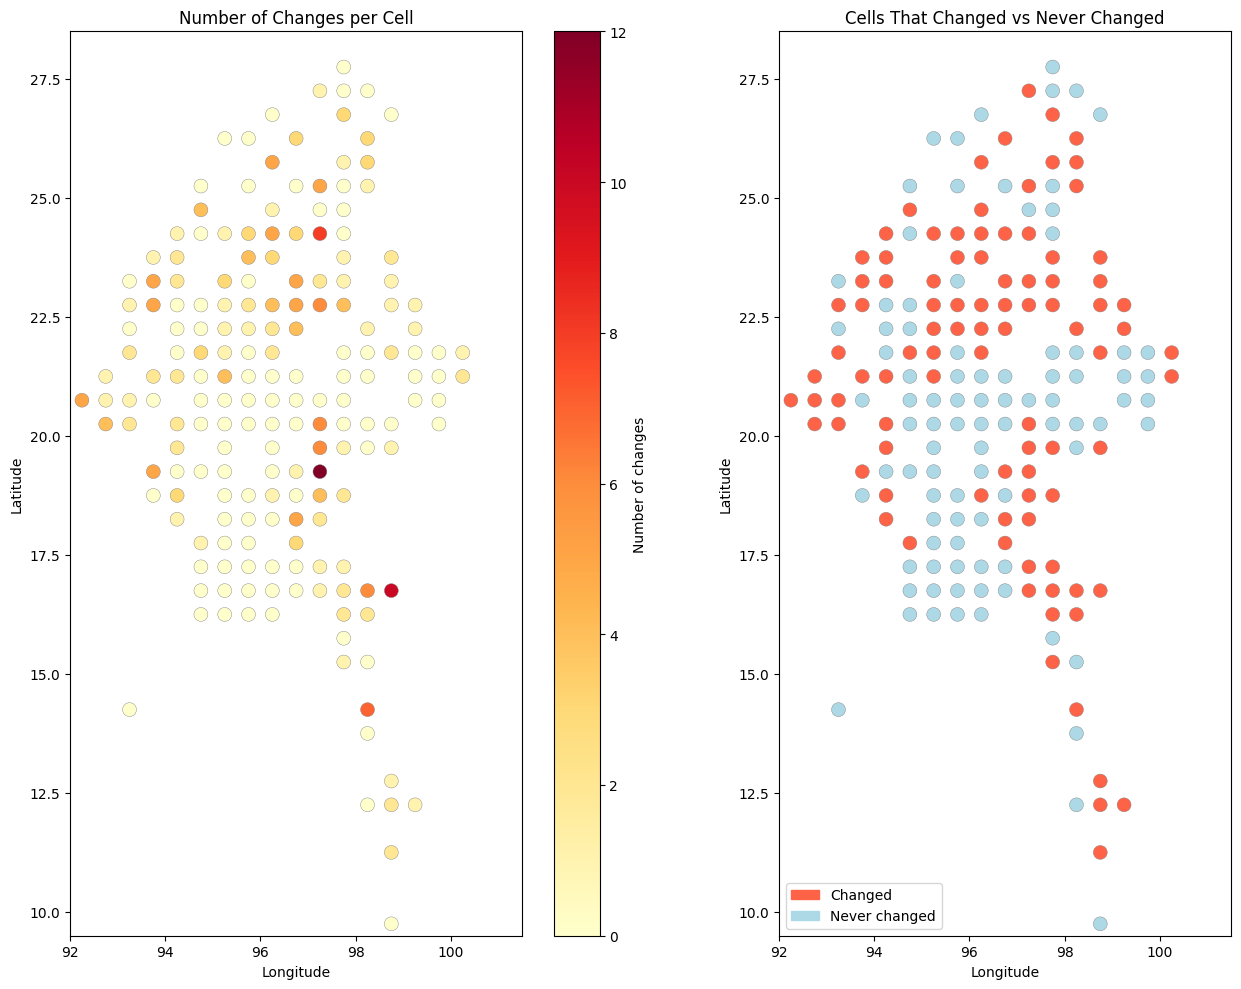

Cells with 0 changes:  91
Cells with 1 change:   35
Cells with 2 changes:  22
Cells with 3+ changes: 37
Max changes in 1 cell: 12 (gid=157515)


In [11]:
def gid_to_latlon(gid):
    row = (gid - 1) // 720
    col = (gid - 1) % 720
    return row * 0.5 - 90 + 0.25, col * 0.5 - 180 + 0.25

changes_per_cell = target[target["changed"]].groupby("priogrid_gid").size()
changes_per_cell = changes_per_cell.reindex(all_cells, fill_value=0)

lats = [gid_to_latlon(g)[0] for g in changes_per_cell.index]
lons = [gid_to_latlon(g)[1] for g in changes_per_cell.index]
vals = changes_per_cell.values

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Left: number of changes
sc = axes[0].scatter(lons, lats, c=vals, cmap="YlOrRd", s=100,
                     vmin=0, vmax=vals.max(), edgecolors="grey", linewidths=0.3)
plt.colorbar(sc, ax=axes[0], label="Number of changes")
axes[0].set_title("Number of Changes per Cell", fontsize=12)
axes[0].set_xlim(92, 101.5); axes[0].set_ylim(9.5, 28.5)
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal")

# Right: ever changed vs never changed
colors_map = ["tomato" if g in changed_cells else "lightblue" for g in changes_per_cell.index]
axes[1].scatter(lons, lats, c=colors_map, s=100, edgecolors="grey", linewidths=0.3)
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="tomato", label="Changed"),
                         Patch(color="lightblue", label="Never changed")],
               loc="lower left")
axes[1].set_title("Cells That Changed vs Never Changed", fontsize=12)
axes[1].set_xlim(92, 101.5); axes[1].set_ylim(9.5, 28.5)
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.savefig(REPORTS / "05_changes_per_cell_map.png", dpi=150)
plt.show()

print(f"Cells with 0 changes:  {(changes_per_cell == 0).sum()}")
print(f"Cells with 1 change:   {(changes_per_cell == 1).sum()}")
print(f"Cells with 2 changes:  {(changes_per_cell == 2).sum()}")
print(f"Cells with 3+ changes: {(changes_per_cell >= 3).sum()}")
print(f"Max changes in 1 cell: {changes_per_cell.max()} (gid={changes_per_cell.idxmax()})")

## 6. Class Persistence

How dominant is each class in cells that change vs cells that never change?

Mean share of time in each class:

Class         All cells   Changing     Stable
--------------------------------------------
gov               0.619      0.474      0.769
opo               0.225      0.316      0.132
uncertain         0.155      0.210      0.099

Majority class share:
  Changing cells: 0.787 (mean)
  Stable cells:   1.000 (mean)


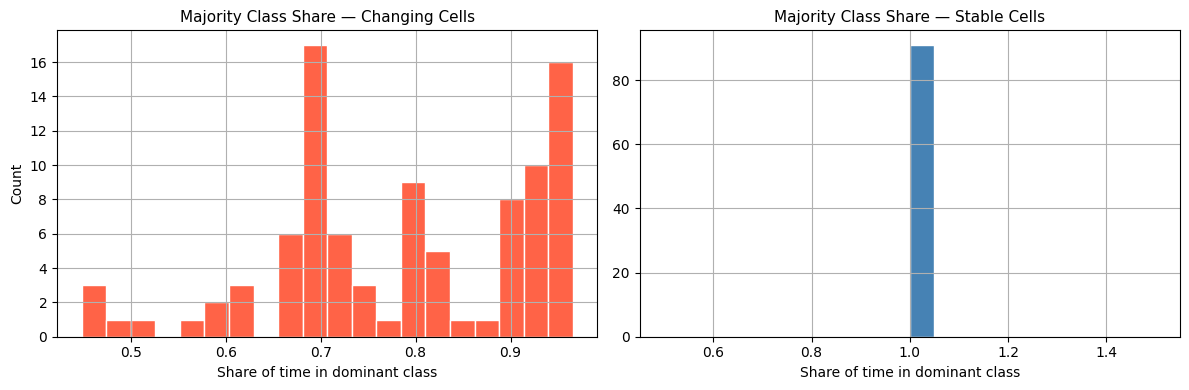

In [12]:
class_shares = target.groupby(["priogrid_gid", "target"]).size().unstack(fill_value=0)
class_shares = class_shares.div(class_shares.sum(axis=1), axis=0)

# Ensure all classes present
for cls in ["gov", "opo", "uncertain"]:
    if cls not in class_shares.columns:
        class_shares[cls] = 0.0

changing_df = class_shares[class_shares.index.isin(changed_cells)]
stable_df   = class_shares[~class_shares.index.isin(changed_cells)]

print("Mean share of time in each class:")
print(f"\n{'Class':<12} {'All cells':>10} {'Changing':>10} {'Stable':>10}")
print("-" * 44)
for cls in ["gov", "opo", "uncertain"]:
    print(f"{cls:<12} {class_shares[cls].mean():>10.3f} "
          f"{changing_df[cls].mean():>10.3f} "
          f"{stable_df[cls].mean():>10.3f}")

print(f"\nMajority class share:")
print(f"  Changing cells: {changing_df.max(axis=1).mean():.3f} (mean)")
print(f"  Stable cells:   {stable_df.max(axis=1).mean():.3f} (mean)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
changing_df.max(axis=1).hist(bins=20, ax=axes[0], color="tomato", edgecolor="white")
axes[0].set_title("Majority Class Share — Changing Cells", fontsize=11)
axes[0].set_xlabel("Share of time in dominant class")
axes[0].set_ylabel("Count")
stable_df.max(axis=1).hist(bins=20, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Majority Class Share — Stable Cells", fontsize=11)
axes[1].set_xlabel("Share of time in dominant class")
plt.tight_layout()
plt.savefig(REPORTS / "06_class_persistence.png", dpi=150)
plt.show()

## 7. Neighbor Behavior at Change Time

When a cell changes, were its neighbors also changing around the same time? This tells us whether changes are isolated or part of a spatial wave.

Mean number of neighbors that changed, by lag before focal cell change:
                     mean    std  sum
lag 0 (same month)  0.800  0.966  204
lag 1 (1m before)   0.486  0.768  124
lag 2 (2m before)   0.368  0.658   89
lag 3 (3m before)   0.359  0.636   83


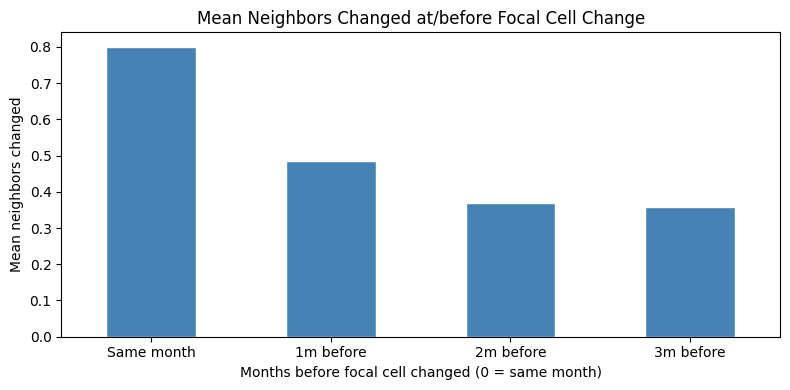

In [13]:
target_idx = target.set_index(["priogrid_gid", "year_month"])

change_events = target[target["changed"]][["priogrid_gid", "year_month"]].copy()

def get_neighbors(gid):
    return {gid-721, gid-720, gid-719, gid-1,
            gid+1, gid+719, gid+720, gid+721} & set(all_cells)

neighbor_data = []
for _, row in change_events.iterrows():
    gid = row["priogrid_gid"]
    ym  = row["year_month"]
    neighbors = get_neighbors(gid)
    ym_idx = all_months.index(ym)

    for lag in [0, 1, 2, 3]:
        if ym_idx - lag < 0:
            continue
        check_ym = all_months[ym_idx - lag]
        n_changed = sum(
            1 for n in neighbors
            if (n, check_ym) in target_idx.index and
            target_idx.loc[(n, check_ym), "changed"]
        )
        neighbor_data.append({
            "priogrid_gid": gid,
            "year_month":   ym,
            "lag":          lag,
            "n_neighbors_changed": n_changed,
            "n_neighbors": len(neighbors)
        })

nc_df = pd.DataFrame(neighbor_data)

print("Mean number of neighbors that changed, by lag before focal cell change:")
summary = nc_df.groupby("lag")["n_neighbors_changed"].agg(["mean", "std", "sum"])
summary.index = [f"lag {i} (same month)" if i == 0 else f"lag {i} ({i}m before)"
                 for i in summary.index]
print(summary.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
nc_df.groupby("lag")["n_neighbors_changed"].mean().plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="white"
)
ax.set_title("Mean Neighbors Changed at/before Focal Cell Change", fontsize=12)
ax.set_xlabel("Months before focal cell changed (0 = same month)")
ax.set_ylabel("Mean neighbors changed")
ax.set_xticklabels([f"{i}m before" if i > 0 else "Same month"
                    for i in range(4)], rotation=0)
plt.tight_layout()
plt.savefig(REPORTS / "07_neighbor_behavior.png", dpi=150)
plt.show()

## Summary

In [14]:
print("=" * 60)
print("EXPLORATION SUMMARY")
print("=" * 60)
print(f"\nTotal cells:                {len(all_cells)}")
print(f"Cells that ever change:     {len(changed_cells)} ({len(changed_cells)/len(all_cells)*100:.1f}%)")
print(f"Total change events:        {target['changed'].sum()}")
print(f"Avg changes per month:      {target['changed'].sum()/len(all_months):.1f}")
print(f"Avg changes per changing cell: {target['changed'].sum()/len(changed_cells):.1f}")
print(f"\nMost common transition:     {transitions.index[0]} ({transitions.iloc[0]} events)")
print(f"\nAll figures saved to: {REPORTS}")

EXPLORATION SUMMARY

Total cells:                185
Cells that ever change:     94 (50.8%)
Total change events:        255
Avg changes per month:      8.8
Avg changes per changing cell: 2.7

Most common transition:     gov -> opo (69 events)

All figures saved to: C:\Users\corne\OneDrive\Nuttige dingen\Verder studeren Spanje\BSE\LEERSTOF\Term3\Thesis\territorial_control_dsdm_master_project\reports\figures
